## Assignment 3

This assignmemt is based on content discussed in modules 3 - 5 and test basic concepts of statistical inference theory and probability distributions.

## Learning outcomes

-   Work on problems of different distributions eg., gaussian 
-   Calculate z score 
-	Make statistical inferences on given data
-	Construct a null and an alternate hypothesis
-	Find the p-value for a given hypothesis and T test statistic.

In [1]:
# Import libraries

import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math
from math import sqrt
from scipy import stats
from scipy.stats import chisquare


### Question 1

The Capital Asset Pricing Model (CAPM) is a financial model that assumes returns on a portfolio are normally distributed.  Suppose a portfolio has an average annual return of 14.7% (i.e., an average gain on 14.7%) with a standard deviation of 33%.  A return of 0% means the value of the portfolio doesn't change, a negative return means that the portfolio loses money, and a positive return means that the portfolio gains money. Determine the following:

1. What percentage of years does this portfolio lose money, (i.e. have a return less than 0%)?
2. What is the cutoff for the highest 15% of annual returns with this portfolio?

See CAPM here https://en.wikipedia.org/wiki/Capital_asset_pricing_model 

### 1.1 

<font color="Blue">What percentage of years does this portfolio lose money, (i.e. have a return less than 0%)?</font>

In [2]:
# Set the mean, the standard deviation and the number of data points.

mu, sigma, num_data_points = .147, .33, 1000

# As the CAPM is a normal distribution, create a normal distribution of portfolio data
# with the mean (average return) and standard deviation.

portfolio_data = np.random.normal(mu, sigma, num_data_points)


C:\Users\camer\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


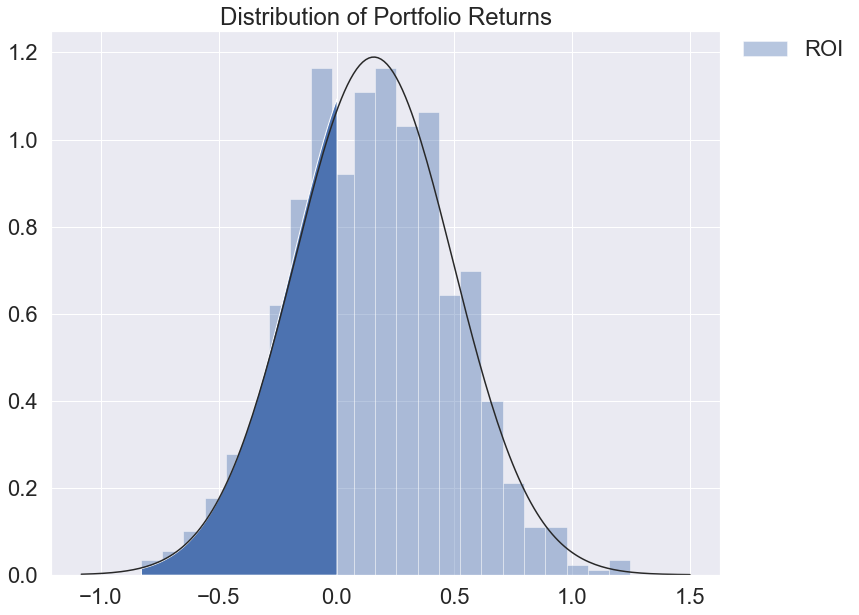

In [3]:
# Create a histogram showing the normal distribution.

plt.style.use('seaborn')
sns.set(font_scale=2)
plt.figure(figsize=(12,10))

x = 0.0
sns.distplot(portfolio_data, label='ROI', kde=False, fit=stats.norm, color='b')

x_plot = np.linspace(min(portfolio_data), x, num_data_points)
y_plot = stats.norm.pdf(x_plot, mu, sigma)
plt.fill_between(x_plot,  y_plot)
c=plt.legend()

plt.title('Distribution of Portfolio Returns')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)


In [4]:
# Calculate the Z score for 0%.

z_score = (x - mu) / sigma
print ("The Z-score for 0 is", round(z_score, 4))

# Calculate the p-score for 0%.

p = stats.norm.cdf(z_score)
print ("The p-score (probability) for this Z-score is", round(p, 4), "\n")
print ("Therefore, the percentage of years this portfolio loses money (an ROI less than 0%) is", round((p* 100), 2), "%")


The Z-score for 0 is -0.4455
The p-score (probability) for this Z-score is 0.328 

Therefore, the percentage of years this portfolio loses money (an ROI less than 0%) is 32.8 %


### 1.2 

<font color="Blue">What is the cutoff for the highest 15% of annual returns with this portfolio?</font>


In [5]:
# Get the lower limit of the top 15% ROI by calculating the 85% quantile.

top_x = np.quantile(portfolio_data, 0.85)
print("The cutoff ROI for the top 15% is", round(top_x*100, 4), '%')


The cutoff ROI for the top 15% is 51.5824 %


In [6]:
# The following is not required but it is working backwards to verify that
# 51.5824% is the top 15%.

# Get the z-score for the cutoff ROI of 49.951%.

top_z_score = (top_x - mu) / sigma

print("The z-score for the cutoff ROI is", round(top_z_score,4))

# Calculate the Cumulative Data Function (CDF) of the cutoff ROI.

top_cdf = stats.norm.cdf(top_z_score)
print("The CDF for 85% quantile (which is the start of the 15% cutoff) is", round(top_cdf, 4))

# The probability of getting an ROI greater than the cutoff ROI is the difference from 1.

print("Therefore, the probability of getting that ROI in a year is", round((1-top_cdf)*100, 2), "%")


The z-score for the cutoff ROI is 1.1176
The CDF for 85% quantile (which is the start of the 15% cutoff) is 0.8681
Therefore, the probability of getting that ROI in a year is 13.19 %


Let's visualize the top 15% ROI cutoff.

C:\Users\camer\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


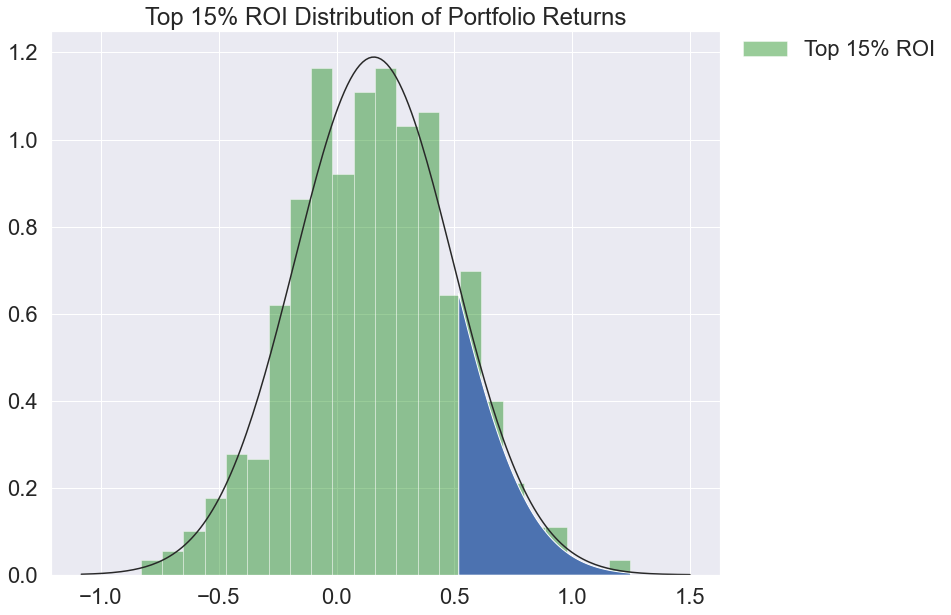

In [7]:
# Plot a histogram of the top 15% ROI returns.

plt.style.use('seaborn')
sns.set(font_scale=2)
plt.figure(figsize=(12,10))

# Set top 15% ROI to be the 85% quantile.

top_15_roi = np.quantile(portfolio_data, 0.85)
sns.distplot(portfolio_data, label='Top 15% ROI', kde=False, fit=stats.norm, color='green')

# Fill in the graph between the maximum of the portfolio data and the top 15 ROI cutoff.

x_plot = np.linspace(max(portfolio_data), top_15_roi, num_data_points)
y_plot = stats.norm.pdf(x_plot, mu, sigma)
plt.fill_between(x_plot, y_plot)
c=plt.legend()


plt.title('Top 15% ROI Distribution of Portfolio Returns')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)


The graph above shows the top 15% ROI values starting at 51.58%.

### Question 2

**Question 2**

Past experience indicates that because of low morale, a company loses 20 hours a year per employee due to lateness and abstenteeism.  Assume that the standard deviation of the population is 6 and normally distributed.

The HR department implemented a new rewards system to increase employee morale, and after a few months it collected a random sample of 20 employees and the annualized absenteeism was 14.

1. Could you confirm that the new rewards system was effective with a 90% confidence?
2. An HR subject matter expert would be very happy if the program could reduce absenteeism by 20% (i.e. to 16 hours).  Given the current sampling parameters (sample size of 20 and std. dev. of population. 6), what is the probability that the new rewards system reduced absenteeism to 16 hours and you miss it?
3. What should the sample size be if you want β to be 5%

### 2.1 

<font color="Blue">Could you confirm that the new rewards system was effective with a 90% confidence?</font>



As the sample size of 20 is smaller than the rule-of-thumb sample size N=30, we generally would not trust the results with a 90% confidence.  However, let's assume this sample size is large enough.

First, visualize the null hypothesis on the sample size, N=20, with a normal distribution centred around the average 20 hours a year lateness / absenteeism from past experience. 

The null hypothesis (_𝐻0_) is that the number of hours of lateness / absenteeism per year did not change from 20 hours per year per employee. 

The alternative hypothesis (_𝐻a_) is that the number of hours of lateness / absenteeism per year has been reduced to 14 hours per year per employee. 

As we are only concerned with the _reduction_ of hours (and not a change in either direction), this is a one-tailed test.  


In [8]:
# Define the variables.

sample_size = 20
sd = 6
h0_mean = 20
ha_observed_mean = 14
alpha = 0.10


Text(0.5, 1.0, 'Null hypothesis Distribution')

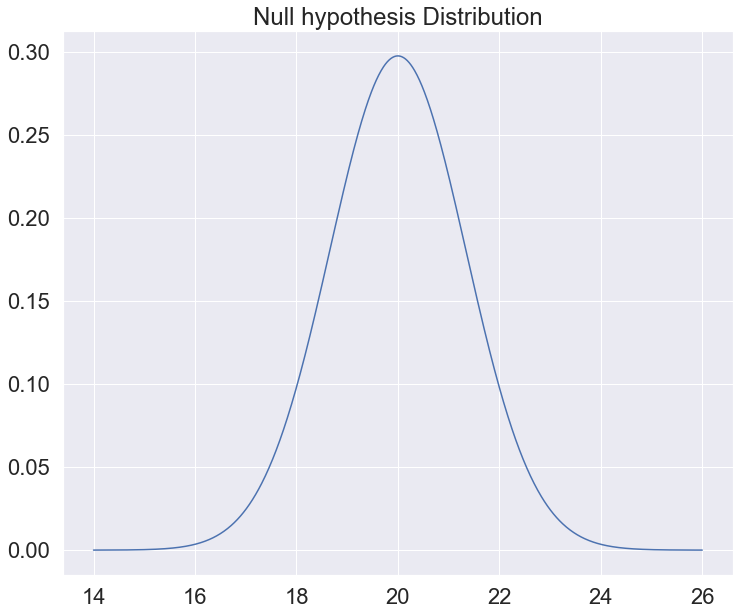

In [9]:
# Create the null hypothesis visualization.  Use the standard deviation from the null hypothesis.

sigma = sd

# Calculate the standard error.

se = sigma/sqrt(sample_size)

plt.figure(figsize=(12,10))

# Create a line of 1000 evenly space numbers for one standard deviation (14 - 26).
# Create a normal distribution centred around the H0 mean of 20.

x = np.linspace((h0_mean-sd), (h0_mean+sd), 1000)   
plt.plot(x, stats.norm.pdf(x, loc=h0_mean, scale=se)) 

plt.title("Null hypothesis Distribution")

We are concerned with the probability of rejecting the null hypothesis when it is actually true.  Therefore, we are looking for the 𝛼 error.
  
For 90% confidence, we need to use 𝛼=0.10.  In other words, we can be 90% confident that the null hypothesis, 𝐻0, is rejected if the sample mean hours are in the lower 10% tail.



Let's calculate the probability (p-value) on the observed sample mean (14 hours) using the cumulative distribution function.


In [10]:
# Calculate the p-value.

p_value= stats.norm.cdf(ha_observed_mean, loc=h0_mean, scale=se)  
print('p-value for given sample is ', p_value)

p-value for given sample is  3.872108215522035e-06


In [11]:
# Calculate the lower 10% based on the Probability Density Function.

x_cr = stats.norm.ppf(alpha, loc=h0_mean, scale=se)
print("The lower 10% in the data is", x_cr)

The lower 10% in the data is 18.280618149662597


The lower 10% in the sample of the null hypothesis is 18.28 or less.  Let's visualize this using 1 standard deviation (14 - 26).

Text(0.5, 1.0, 'Lower 10% of the Null Hypothesis Distribution')

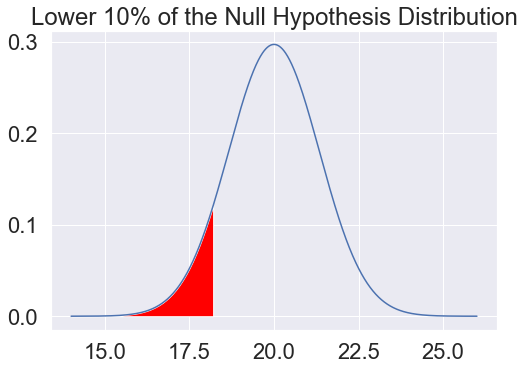

In [12]:
# Plot a distribution showing the lower 10%.

plt.plot(x, stats.norm.pdf(x, loc=h0_mean, scale=se))

plt.fill_between(x=np.arange((h0_mean-sd), x_cr, alpha), y1=stats.norm.pdf(np.arange((h0_mean-sd), x_cr, alpha), loc=h0_mean, scale=se),
                 facecolor='red') 
plt.title("Lower 10% of the Null Hypothesis Distribution")

For this sample, N=20, the p-value = 0.00000387 is much smaller than the significance level $\alpha=0.1$. 

The null hypothesis is rejected when our sample mean falls in the red area. This red area marks the chosen significance level $\alpha=0.1$. 

Assuming that the sample size, N=20 is large enough, the sample mean of 14 falls within the red area so the null hypothesis is rejected with a confidence of 90%.  The conclusion would be that the collected sample confirms the reduction of lateness / absenteeism per employee per year.

### 2.2

<font color="Blue">An HR subject matter expert would be very happy if the program could reduce absenteeism by 20% (i.e. to 16 hours).  Given the current sampling parameters (sample size of 20 and std. dev. of population. 6), what is the probability that the new rewards system reduced absenteeism to 16 hours and you miss it? </font>



We are now looking at how likely it is that we can detect the effect of a reduction from 20 hours to 16 hours.

To calculate the probability that we can reject the null hypothesis, 𝐻0, we will need to add another sampling distribution around 16 hours (20 - 4 hours, or a 20% reduction).
  

In [13]:
# Define variables.

ha_target_mean = 16


Text(0.5, 1.0, 'Null and Target Mean Distribution Intersection')

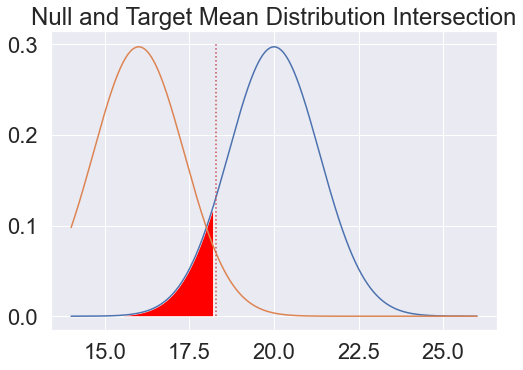

In [14]:
# Visualize the intersection between the two distribusions, one centred around the H0 mean,
# and the other centred around the Ha target mean.

# For reference.
#
# 20 is the null hypothesis
# 16 is the alternative hypothesis
# 14 is 1 sd from 20 (6)
# 18.28 is the alpha=.10 limit

plt.plot(x, stats.norm.pdf(x, loc=h0_mean, scale=se))    
plt.fill_between(x=np.arange((h0_mean-sd), x_cr, alpha), y1=stats.norm.pdf(np.arange((h0_mean-sd), x_cr, alpha), loc=h0_mean, scale=se), facecolor='red')
plt.plot(x, stats.norm.pdf(x, loc=ha_target_mean, scale=se))    
plt.fill_between(x=np.arange((h0_mean-sd), x_cr, alpha), y1=stats.norm.pdf(np.arange((h0_mean-sd), x_cr, alpha), loc=h0_mean, scale=se),
                 facecolor='red')  
plt.vlines(18.280618149662597, 0, .3, colors='r', linestyles='dotted')

plt.title("Null and Target Mean Distribution Intersection")

The null hypothesis will be rejected when the sample mean is to the left of the dotted line. On the "null" curve this dotted line marks the rejection region which corresponds to the defined significance level $\alpha = 0.1$ (area in red).

The area under the orange curve to the left of the dotted line defines the probability to detect a sample with a mean of 18.28 or less, which is what we're looking for.

In [15]:
# Calculate the power of test.

power_of_test = stats.norm.cdf(x_cr, loc=ha_target_mean, scale=se) 
print('The power of test when the reduction is 16 hours and sample size is 20: ', power_of_test)


The power of test when the reduction is 16 hours and sample size is 20:  0.9554225356966211


A reduction of 4 hours (20%) to 16 hours is the minimum reduction we can detect (it could be a larger reduction) with a probability of ~96%.  This makes sense as that line is pretty far to the left of the alternative hypothesis orange curve.


Let's find what sample size is required to get a power of test of 90% and a significance level of 1%. 

In [16]:
# Calculate the Z-score for 1% significance level.

Z_a = stats.norm.ppf(0.01)

# Calculate the Z-score for 90% power of test.
Z_b = stats.norm.ppf(0.90)

print('The Z-score for 1% is', Z_a)
print('The Z-score for 90% is', Z_b)


The Z-score for 1% is -2.3263478740408408
The Z-score for 90% is 1.2815515655446004


In [17]:
# Calculate the probability of missing the reduction in lateness / absenteeism.

se = (h0_mean-ha_target_mean) / (np.abs(Z_a)+np.abs(Z_b))
n_samples = np.square(sd/se) 

se_new = sigma/sqrt(n_samples)
x_crit_new = h0_mean + stats.norm.ppf(0.01) * se_new   # 3

print('New critical value', x_crit_new)

power_of_test_new = stats.norm.cdf(x_crit_new, loc=ha_target_mean, scale=se_new)
print('The power of test for new sample size and significance level 1% is', power_of_test_new)

miss_reduction_prop = 1 - power_of_test_new

print('The probability of missing the reduction in sick time is', miss_reduction_prop)

New critical value 17.420828475964235
The power of test for new sample size and significance level 1% is 0.8999999999999999
The probability of missing the reduction in sick time is 0.10000000000000009


This power of test value tells us that the probability to miss the reduction of lateness / absenteeism time by 4 hours from the potential sample of 19 is 1 - 0.90 = 0.09999 (10%).

### 2.3 

<font color="Blue">3. What should the sample size be if you want β to be 5%</font>

In [18]:
# Calculate the Z-score for B=5%.

Z_5a = stats.norm.ppf(0.05)

# Calculate the Z-score for 90% power of test.

Z_b = stats.norm.ppf(0.90)

print('The Z-score for 5% is', Z_5a)
print('The Z-score for 90% is', Z_b)


The Z-score for 5% is -1.6448536269514729
The Z-score for 90% is 1.2815515655446004


In [19]:
# Calculate the standard error for B=5%.

# SE = H0 mean - Ha mean / Z-Score(5%) + Z-Score(90%) 

se5 = (h0_mean-ha_target_mean) / (np.abs(Z_5a)+np.abs(Z_b))

# Calculate the number of samples required.

n_samples = np.square(sd/se5) 
print("The sample size for Beta=5% is", n_samples)

The sample size for Beta=5% is 19.268656539002954


For 5% error rate, the number of samples needs to be 20 (cannot have 1/4 of a person).

### Question 3

Chi-Square Goodness of fit

Please access and review **section 6.3.5** in the OpenIntro Statistics textbook:

Diez, D., Çetinkaya-Rundel, M. & Barr, C (2019). OpenIntro Statistics (4th Ed.). https://leanpub.com/openintro-statistics

Given the information in section 6.3.5, write python code for the following:

 - Calculate the expected values based on the geometric distribution with a probability of 53.2%
 - Compare the expected vs. the observed values from the textbook using the Chi-Square distribution
 - Reach a conclusion
 - Explain what is the business impact of your conclusion

In [20]:
_total_count = 1362

# geometric distribution calculation

def calculate_probability(prob, day):

    # Calculate the geometric model distribution.
        
    return ((1 - prob)**(day-1)) * prob
    

def calculate_expected_results(prob):
    
    # Empty DataFrame.
    
    p_df = pd.DataFrame(columns=['Bin', 'Probability', 'Percentage', 'Value'])

    # Iterate over the bins (1 - 7).
    
    for i in range(1,8):
        
        # Calculate the expected count by determining the null proportion associated
        # with the bin multiplied by the total count.  This calculates the proportion 
        # from the total count is expected in each bin.

        my_percentage = round(calculate_probability(prob, i), 4)
        
        expected_count = math.ceil(round(my_percentage * _total_count, 2))
               
        # Create a temporary DataFrame and append it to the primary DataFrame.
        
        bin_df = pd.DataFrame({'Bin' : [i], 'Probability' : [prob], \
                               'Percentage' : my_percentage, \
                               'Value' : [expected_count]})
        
        p_df = pd.concat([p_df, bin_df], ignore_index=True, axis=0)

    return p_df  


def add_observed_values():

    # Set the observed values for each bin.
    
    bins = [1, 2, 3, 4, 5, 6, 7]
    bin_values = [717, 369, 155, 69, 28, 14, 10]
    index = ['1', '2', '3', '4', '5', '6', '7']

    # Create the base DataFrame.
    
    obs_df = pd.DataFrame({'Bin': bins,
                           'Value': bin_values}, index=index)
    
    # Add in the Probability ID and the value for the bin.
    
    obs_df = obs_df.assign(Probability='Observed')
    obs_df = obs_df.assign(Percentage=round(obs_df['Value'] / _total_count, 4))
    
    return obs_df

In [21]:
# Calculate the expected results for 53.2% up day and add the observed values.

exp_df = calculate_expected_results(.532)
obs_df = add_observed_values()

# Combine the results together into one DataFrame.

all_df = pd.concat([exp_df, obs_df], ignore_index=True, axis=0)
all_df = all_df.sort_values(by=['Percentage'], ascending = False)

all_df

,Bin,Probability,Percentage,Value
0,1,0.532,0.532,725
7,1,Observed,0.5264,717
8,2,Observed,0.2709,369
1,2,0.532,0.249,340
2,3,0.532,0.1165,159
9,3,Observed,0.1138,155
3,4,0.532,0.0545,75
10,4,Observed,0.0507,69
4,5,0.532,0.0255,35
11,5,Observed,0.0206,28


C:\Users\camer\anaconda3\lib\site-packages\pandas\core\algorithms.py:798: FutureWarning: In a future version, the Index constructor will not infer numeric dtypes when passed object-dtype sequences (matching Series behavior)
  uniques = Index(uniques)


<Figure size 864x720 with 0 Axes>

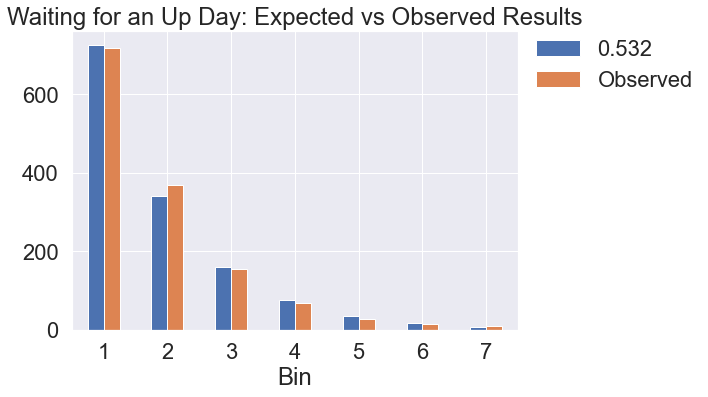

In [22]:
# Create a pivot table of the Probability (including Observed values) and their values
# for each bin.

diag_df = all_df.pivot(index='Bin', columns='Probability', values='Value')

# Plot a bar chart based on this pivot table.

plt.style.use('seaborn')
sns.set(font_scale=2)

plt.figure(figsize=(12,10))
ax = diag_df.plot.bar(rot=0)
plt.title('Waiting for an Up Day: Expected vs Observed Results')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)


### Observations:

The above shows the distribution of the waiting time in days between positive trading days.  The observed results from the S&P500 was positive on 54.5% of those days.  The expected results were  calculated based on the results being positive 53.2% of those days.
 
Visually observing the data, it appears that the expected results follow a geometric distribution.  However, it is not possible to determine if the difference between the expected and observed results are statistically significant.  Therefore, we can perform a Chi-Square Test.


### Chi-Square Test

The Chi-Square framework requires expected counts to be at least 5 and with binning the wait days above into 7 days, the counts meet this threshold.

Let's set the null and alternative hypotheses using those that were found in the textbook, _Diez, D., Çetinkaya-Rundel, M. & Barr, C (2019). OpenIntro Statistics (4th Ed.)_.

- H0: The stock market being up or down on a given day is independent from all other days. We
will consider the number of days that pass until an Up day is observed. Under this hypothesis,
the number of days until an Up day should follow a geometric distribution.

- HA: The stock market being up or down on a given day is not independent from all other days.
Since we know the number of days until an Up day would follow a geometric distribution under
the null, we look for deviations from the geometric distribution, which would support the
alternative hypothesis.

The Chi-Square test will be done using a degrees of freedom (df) of 7 bins - 1; df = 7-1 = 6

Using the Chi-Square formula, X^2 = (O1-E1)^2/E1 + (O1-E1)^2/E1 + ... + (O7-E7)^2/E7, where O = observed value for that bin and E is the expected value for that bin

We get the following:  X^2 = (717-725)^2/725 + (369-340)^2/340 + ... + (10-8)^2/8 = 5.57

Using the Chi-Square p-value calculator: https://www.socscistatistics.com/pvalues/chidistribution.aspx

The df = 6 and a X^2 = 5.57, the p-value is: .473

Therefore, this pattern would occur only 47.3% of the time.  This is not statistically significant for a p < 0.05.

In [23]:
# An alternative to using the Chi-Square p-value calculator is to use the stats library.
# However, the observed and expected values have to be exact.  Therefore, add a couple of
# values to account for rounding (the result is still the same).

test = chisquare([717, 369, 155, 69, 28, 14, 10], f_exp=[725, 340, 159, 75, 36, 18, 9])

print('The Chi-square value is %.2f' %test.statistic)
print('And the p-value is %.2f' %test.pvalue)


The Chi-square value is 5.92
And the p-value is 0.43


### Conclusion

Based on the results not being statistically significant, we cannot say with 95% confidence that the wait times for an up day are based on a geometric pattern.  We therefore cannot reject the null hypothesis that the stock market is independent of each day.  

We cannot predict with any confidence when stocks will rise, or have another up day, based on this model. The business impact of this conclusion is that it would be imprudent just to simply wait it out for an up day (i.e., the stock hasn't risen in a few days so it's due to rise in the next trading session).  There are other factors that need to be taken into consideration to determine if a stock will rise.